In [1]:
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cf
import matplotlib.cm as cm
import matplotlib.colors as colors
import matplotlib.colors as mcolors
import pickle
import matplotlib.pyplot as plt
import sys


sys.path.append("../") 
import WRFDomainLib
# Example usage
def plasma_white(vmin=-1, vmax=6):
    # Start with inferno
    inferno = cm.get_cmap("plasma_r", 256)
    # Replace the first color with white
    colors = inferno(np.linspace(0, 1, 256))
    colors[0] = np.array([1, 1, 1, 1])  # RGBA for white
    return mcolors.LinearSegmentedColormap.from_list("plasma_white", colors)
cmap = plasma_white()#inferno_white()

mpl.rcParams['hatch.linewidth'] = 0.1
mpl.rcParams['patch.edgecolor']='none'
WPSFile = '/gpfs/fs7/dfo/hpcmc/pfm/spfm000/CanESM2-WRF/plotting_files/namelist.wps.txt'
wpsproj, latlonproj, corner_lat_full, corner_lon_full, length_x, length_y = WRFDomainLib.calc_wps_domain_info(WPSFile)

seasons = [ 'SON', 'JJA', 'MAM','DJF']


ERROR 1: PROJ: proj_create_from_database: Open of /home/amh001/space_fs7/software_2022/python/py_2024/share/proj failed
/tmp/amh001/1173/ipykernel_1385/893277618.py:19: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  inferno = cm.get_cmap("plasma_r", 256)


In [2]:
at=0.1;bt=0.9

# Define grid shape (rows, columns)
nrows = len(seasons)
ncols = 4
sublist=['a', 'b', 'c', 'd', 'e', 'f', 'g', 'h', 'i', 'j', 'k', 'l', 'm', 'n', 'o','p', 'q', 'r', 's', 't', 'u']
# Reshape and transpose
subpanel = np.array(sublist[:nrows * ncols]).reshape(nrows, ncols).T.flatten().tolist()

label={"t": r" $\Delta$ T$_{95p}$ ($^\circ$C) ", "tmin":r"$\Delta$ T$_{5p}$ ($^\circ$C)", "pr": '$\Delta$ P$_{95p}$ (%)', "wind": '$\Delta$ Wspd$_{95p}$ (%)'}
var_cmaps = {"t":plasma_white(0,8),"tmin":plasma_white(0,8), "pr":"BrBG", "wind":"PuOr"}
vlims = {"tmin":(0,8),"t":(0,8), "pr":(-60,60), "wind":(-20,20)}

# Hatching where pval < 0.1
dense_dots = "." * 3  # repeat the dot
hatch_pattern = dense_dots # + " " + dense_dots  # optional spacing


/tmp/amh001/1173/ipykernel_1385/893277618.py:19: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  inferno = cm.get_cmap("plasma_r", 256)


In [3]:
def getseasons(var, period, perc, rel, med):
    
    if med=='_med':
        p0 = 75 if var == 'pr' else 50
    else:
        p0=''
    season_data = {}
    for s in seasons:
        filepath=f'/gpfs/fs7/dfo/hpcmc/pfm/amh001/DATA/WRF/Extremes/{var}_{s}_{period}_boots_years_1000_perc_{perc}{rel}{med}{p0}.pkl'
        
        print('filepath', filepath)
        # ---- Load results ----
        with open(filepath, "rb") as f:
            data = pickle.load(f)
        perc_delta=data['perc_delta']
        p_val = data["p_value"]
        print(s,perc_delta.mean())
        season_data[s] = (data[f"perc_delta"], data[f"p_value"])
    return season_data

In [4]:
#seasons = [ 'SON', 'JJA', 'MAM','DJF']
seasons = ["DJF", "MAM", "JJA", "SON"]

var='T2'; period='rcp45'; perc=95; rel=''; med='_med'
season_data_t = getseasons(var, period, perc, rel, med)
var='pr'; rel='_rel'
season_data_pr = getseasons(var, period, perc, rel, '_med75')
var='wspd'; rel='_rel'
season_data_wind = getseasons(var, period, perc, rel, med)
var='T2';  perc=5; rel=''
season_data_tmin = getseasons(var, period, perc, rel, med)


filepath /gpfs/fs7/dfo/hpcmc/pfm/amh001/DATA/WRF/Extremes/T2_DJF_rcp45_boots_years_1000_perc_95_med50.pkl
DJF -0.7112492235989042
filepath /gpfs/fs7/dfo/hpcmc/pfm/amh001/DATA/WRF/Extremes/T2_MAM_rcp45_boots_years_1000_perc_95_med50.pkl
MAM -0.8985923557740668
filepath /gpfs/fs7/dfo/hpcmc/pfm/amh001/DATA/WRF/Extremes/T2_JJA_rcp45_boots_years_1000_perc_95_med50.pkl
JJA 0.11100098698086193
filepath /gpfs/fs7/dfo/hpcmc/pfm/amh001/DATA/WRF/Extremes/T2_SON_rcp45_boots_years_1000_perc_95_med50.pkl
SON -0.0707709877127188
filepath /gpfs/fs7/dfo/hpcmc/pfm/amh001/DATA/WRF/Extremes/pr_DJF_rcp45_boots_years_1000_perc_95_rel_med75.pkl
DJF 12.206199489651567
filepath /gpfs/fs7/dfo/hpcmc/pfm/amh001/DATA/WRF/Extremes/pr_MAM_rcp45_boots_years_1000_perc_95_rel_med75.pkl
MAM 4.065849777507979
filepath /gpfs/fs7/dfo/hpcmc/pfm/amh001/DATA/WRF/Extremes/pr_JJA_rcp45_boots_years_1000_perc_95_rel_med75.pkl
JJA -22.58428831683875
filepath /gpfs/fs7/dfo/hpcmc/pfm/amh001/DATA/WRF/Extremes/pr_SON_rcp45_boots_years

In [5]:
#seasons = [ 'SON', 'JJA', 'MAM','DJF']
seasons = ["DJF", "MAM", "JJA", "SON"]

var='T2'; period='rcp85'; perc=95; rel=''; med='_med'
season_data_t_85 = getseasons(var, period, perc, rel, med)
var='pr'; rel='_rel'
season_data_pr_85 = getseasons(var, period, perc, rel, '_med75')
var='wspd'; rel='_rel'
season_data_wind_85 = getseasons(var, period, perc, rel, med)
var='T2';  perc=5; rel=''
season_data_tmin_85 = getseasons(var, period, perc, rel, med)

filepath /gpfs/fs7/dfo/hpcmc/pfm/amh001/DATA/WRF/Extremes/T2_DJF_rcp85_boots_years_1000_perc_95_med50.pkl
DJF -0.7167332463653001
filepath /gpfs/fs7/dfo/hpcmc/pfm/amh001/DATA/WRF/Extremes/T2_MAM_rcp85_boots_years_1000_perc_95_med50.pkl
MAM -0.9674408595650282
filepath /gpfs/fs7/dfo/hpcmc/pfm/amh001/DATA/WRF/Extremes/T2_JJA_rcp85_boots_years_1000_perc_95_med50.pkl
JJA 0.2462116462156506
filepath /gpfs/fs7/dfo/hpcmc/pfm/amh001/DATA/WRF/Extremes/T2_SON_rcp85_boots_years_1000_perc_95_med50.pkl
SON -0.0314530088594224
filepath /gpfs/fs7/dfo/hpcmc/pfm/amh001/DATA/WRF/Extremes/pr_DJF_rcp85_boots_years_1000_perc_95_rel_med75.pkl
DJF nan
filepath /gpfs/fs7/dfo/hpcmc/pfm/amh001/DATA/WRF/Extremes/pr_MAM_rcp85_boots_years_1000_perc_95_rel_med75.pkl
MAM nan
filepath /gpfs/fs7/dfo/hpcmc/pfm/amh001/DATA/WRF/Extremes/pr_JJA_rcp85_boots_years_1000_perc_95_rel_med75.pkl
JJA nan
filepath /gpfs/fs7/dfo/hpcmc/pfm/amh001/DATA/WRF/Extremes/pr_SON_rcp85_boots_years_1000_perc_95_rel_med75.pkl
SON 26.8388490790

In [14]:
import matplotlib.ticker as mticker
from cartopy.mpl.ticker import LongitudeFormatter, LatitudeFormatter

def plotseasons(j, count, season_data, axes, seasons, nmodels, var):
    vmin=vlims[var][0];vmax=vlims[var][1]
    
    for i, season in enumerate(seasons):
        ax = axes[i, j] if nmodels > 1 else axes[i]
        field = season_data[season][0]
        pval  = season_data[season][1]
        
        # Main colormap
        mesh = ax.pcolormesh(
            lon, lat, field,
            cmap=var_cmaps[var], vmin=vmin,vmax=vmax,
            transform=ccrs.PlateCarree()    )
        
        cs = ax.contourf(
            lon, lat, pval,
            levels=[0.1, 1],
            colors="none", 
            hatches=[hatch_pattern],
            transform=ccrs.PlateCarree()
        )
        coastline = cf.COASTLINE.with_scale('10m')
        ax.add_feature(coastline, linewidth=0.1, edgecolor='black')
        # 3. Create the Gridliner object
        #gl = ax.gridlines(crs=ccrs.PlateCarree(), draw_labels=True,
                      #    linewidth=1, color='gray', alpha=0.5, linestyle='--')
        
        # 4. Customize the Gridliner object
        # --- Remove labels on the top and right sides ---
        #gl.top_labels = False
        #gl.right_labels = False
        
        # --- Set the frequency of the gridlines ---
        # Use matplotlib.ticker to define the interval of the lines
       # gl.xlocator = mticker.FixedLocator(range(-180, 180, 2)) # Longitude lines every 10 degrees
        #gl.ylocator = mticker.FixedLocator(range(48,56, 4))   # Latitude lines every 5 degrees
        
        # --- Format the labels to include N/S/E/W ---
        #gl.xformatter = LongitudeFormatter()
        #gl.yformatter = LatitudeFormatter()
        ax.text(at, bt, subpanel[count], transform=ax.transAxes,  va='top', fontweight='normal',zorder=1000)
        if j==0:
            ax.text(-0.18, 0.6, season, transform=ax.transAxes,  va='top', fontweight='normal',zorder=1000, rotation='vertical')
        ax.set_extent([-129.6, -120.15, 46.4, 51.7], crs=ccrs.PlateCarree())
        
        count+=1
        
        # This stays INSIDE the for loop
        if i == len(seasons) - 1:  # After last row in the column
            bbox = ax.get_position()
            cbar_ax = fig.add_axes([
                bbox.x0, bbox.y0 - 0.03,
                bbox.width, 0.015
            ])
            cbar = fig.colorbar(mesh, cax=cbar_ax, extend='both', orientation="horizontal")
            cbar.set_label(label[var], fontsize=10)
            cbar.set_ticks([vmin,(vmax-abs(vmin))/2,vmax])
    
    # Bracket code OUTSIDE the for loop
    # RCP 4.5 bracket (columns 0-1)
    if j == 1:
        bbox0 = axes[0, 0].get_position()
        bbox1 = axes[0, 1].get_position()
        bracket_y = bbox0.y1 + 0.02
        bracket_height = 0.01
        fig.add_artist(plt.Line2D([bbox0.x0, bbox0.x0], [bracket_y, bracket_y + bracket_height], 
                                  transform=fig.transFigure, color='black', linewidth=1.5))
        fig.add_artist(plt.Line2D([bbox0.x0, bbox1.x1], [bracket_y + bracket_height, bracket_y + bracket_height], 
                                  transform=fig.transFigure, color='black', linewidth=1.5))
        fig.add_artist(plt.Line2D([bbox1.x1, bbox1.x1], [bracket_y + bracket_height, bracket_y], 
                                  transform=fig.transFigure, color='black', linewidth=1.5))
        fig.text((bbox0.x0 + bbox1.x1) / 2, bracket_y + bracket_height + 0.01, 'RCP 4.5',
                ha='center', va='bottom', fontsize=10, fontweight='medium')
    
    # RCP 8.5 bracket (columns 2-3)
    if j == 3:
        bbox2 = axes[0, 2].get_position()
        bbox3 = axes[0, 3].get_position()
        bracket_y = bbox2.y1 + 0.02
        bracket_height = 0.01
        fig.add_artist(plt.Line2D([bbox2.x0, bbox2.x0], [bracket_y, bracket_y + bracket_height], 
                                  transform=fig.transFigure, color='black', linewidth=1.5))
        fig.add_artist(plt.Line2D([bbox2.x0, bbox3.x1], [bracket_y + bracket_height, bracket_y + bracket_height], 
                                  transform=fig.transFigure, color='black', linewidth=1.5))
        fig.add_artist(plt.Line2D([bbox3.x1, bbox3.x1], [bracket_y + bracket_height, bracket_y], 
                                  transform=fig.transFigure, color='black', linewidth=1.5))
        fig.text((bbox2.x0 + bbox3.x1) / 2, bracket_y + bracket_height + 0.01, 'RCP 8.5',
                ha='center', va='bottom', fontsize=10, fontweight='medium')
    
    return count

In [7]:
#load lats and lons like this for now, but need to add to extremes
filepath='/gpfs/fs7/dfo/hpcmc/pfm/amh001/DATA/WRF/MEANS/seasonal_deltas_and_pvals_pr_rcp45_d03.npz'
data = np.load(filepath)
lat= data ['lat']
lon=data['lon']

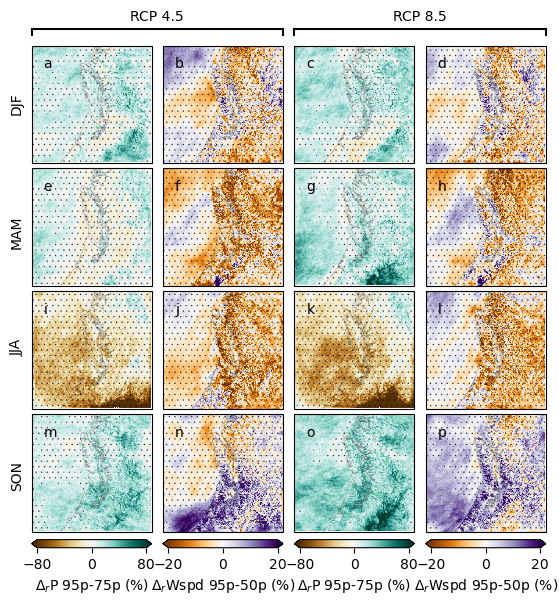

In [20]:
seasons = ["DJF", "MAM", "JJA", "SON"]

nrows = len(seasons)
subpanel = np.array(sublist[:nrows * ncols]).reshape(nrows, ncols).T.flatten().tolist()

var_cmaps = {"t":'RdBu_r',"tmin":'RdBu_r', "pr":"BrBG", "wind":"PuOr"}
vlims = {"tmin":(-4,4),"t":(-4,4), "pr":(-80,80), "wind":(-20,20)}
nmodels=4;
# Hatching where pval < 0.1
label={"t": r" $\Delta_r$T 95p-50p ($^\circ$C) ", "tmin":r"$\Delta_r$T 50p-5p ($^\circ$C)", "pr": '$\Delta_r$P 95p-75p (%)', "wind": '$\Delta_r$Wspd 95p-50p (%)'}
fig, axes = plt.subplots(
        nrows=len(seasons), ncols=nmodels,
        figsize=(6.7,5.4),
        subplot_kw={"projection": wpsproj}
    )
fig.subplots_adjust(bottom=0.05, hspace=0.05, wspace=0.05, top=0.95)

count=0
count=plotseasons(0, count, season_data_pr, axes, seasons, nmodels, 'pr')
count=plotseasons(1, count, season_data_wind, axes, seasons, nmodels, 'wind')
count=plotseasons(2, count, season_data_pr_85, axes, seasons, nmodels, 'pr')
count=plotseasons(3, count, season_data_wind_85, axes, seasons, nmodels, 'wind')
plt.savefig('../Figures/Extremes_median_pr_wind.png', format='png', bbox_inches='tight',transparent=False,dpi=500)
plt.show()
plt.close(fig)

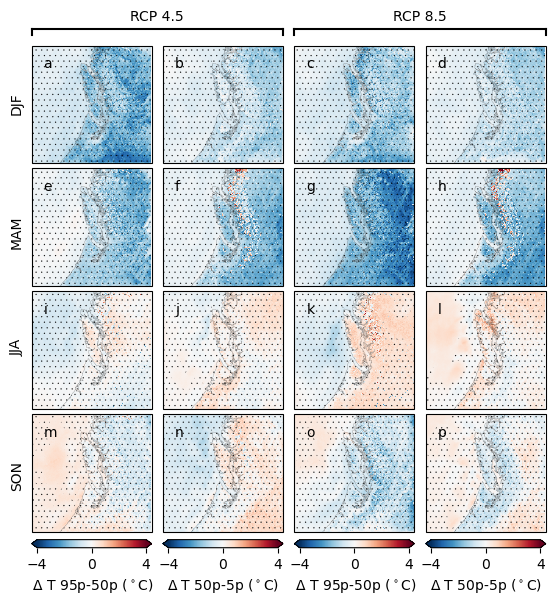

In [18]:
#seasons = [ 'SON', 'JJA', 'MAM','DJF']
nrows = len(seasons)
subpanel = np.array(sublist[:nrows * ncols]).reshape(nrows, ncols).T.flatten().tolist()

var_cmaps = {"t":'RdBu_r',"tmin":'RdBu_r', "pr":"BrBG", "wind":"PuOr"}
vlims = {"tmin":(-4,4),"t":(-4,4), "pr":(-80,80), "wind":(-20,20)}
nmodels=4;
# Hatching where pval < 0.1
label={"t": r" $\Delta$ T 95p-50p ($^\circ$C) ", "tmin":r"$\Delta$ T 50p-5p ($^\circ$C)", "pr": '$\Delta$ P 95p-75p (%)', "wind": '$\Delta$ Wspd 95p-50p (%)'}
fig, axes = plt.subplots(
        nrows=len(seasons), ncols=nmodels,
        figsize=(6.7,5.4),
        subplot_kw={"projection": wpsproj}
    )
fig.subplots_adjust(bottom=0.05, hspace=0.05, wspace=0.05, top=0.95)

count=0
count=plotseasons(0, count, season_data_tmin, axes, seasons, nmodels, 't')
count=plotseasons(1, count, season_data_t, axes, seasons, nmodels, 'tmin')
count=plotseasons(2, count, season_data_tmin_85, axes, seasons, nmodels, 't')
count=plotseasons(3, count, season_data_t_85, axes, seasons, nmodels, 'tmin')
plt.savefig('../Figures/Extremes_median_temp.png', format='png', bbox_inches='tight',transparent=False,dpi=500)
plt.show()
plt.close(fig)